In [ ]:
!pip install torchmetrics
!pip install grad-cam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=88d9e9dc3a7a5b12a831fcbe95a36f3e1c45b0dd8564f125f40af8efc3ab9938
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
!pip install -q hf-transfer
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.7 MB/s eta 0:00:00


In [ ]:
!GIT_TERMINAL_PROMPT=0 git clone --progress \
    https://huggingface.co/datasets/Godseye1311/geometry-stress-strain-fea \
    /content/dataset 2>&1 | tee /content/clone_log.txt

Cloning into '/content/dataset'...
remote: Enumerating objects: 47340, done.        
remote: Total 47340 (delta 0), reused 0 (delta 0), pack-reused 47340 (from 1)        
Receiving objects: 100% (47340/47340), 6.57 MiB | 9.44 MiB/s, done.
Resolving deltas: 100% (132/132), done.
Updating files: 100% (47004/47004), done.
Filtering content: 100% (47002/47002), 7.88 GiB | 4.22 MiB/s, done.


In [ ]:
!git lfs install
!git clone https://huggingface.co/datasets/Godseye1311/geometry-stress-strain-fea /content/data

Git LFS initialized.
Cloning into '/content/data'...
remote: Enumerating objects: 47340, done.
remote: Total 47340 (delta 0), reused 0 (delta 0), pack-reused 47340 (from 1)
Receiving objects: 100% (47340/47340), 6.57 MiB | 9.10 MiB/s, done.
Resolving deltas: 100% (131/131), done.
Updating files: 100% (47004/47004), done.
Filtering content: 100% (47002/47002), 7.88 GiB | 5.77 MiB/s, done.


In [ ]:
import os, glob, math, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.functional import structural_similarity_index_measure as ssim_func

# ── Dataset config ──────
ALL_SUBDATASETS = [
    "BC_scale",
    "FIELD2GEO/STITCH(S11_GEO_color_rescale)",
    "HEXAGON",
    "MISES",
    "PE11_0.2",
    "PE12",
    "S11",
    "S12",
    "STITCH(GEO_MISES)",
    "TRIANGLE",
]

IMG_SIZE   = 128
BATCH_SIZE = 4
EPOCHS     = 25
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP    = False   # float16 causes NaN on this GPU — keep float32

print(f"Device : {DEVICE}  |  AMP: {USE_AMP}")
print(f"Subdatasets ({len(ALL_SUBDATASETS)}): {ALL_SUBDATASETS}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


Device : cuda  |  AMP: False
Subdatasets (10): ['BC_scale', 'FIELD2GEO/STITCH(S11_GEO_color_rescale)', 'HEXAGON', 'MISES', 'PE11_0.2', 'PE12', 'S11', 'S12', 'STITCH(GEO_MISES)', 'TRIANGLE']


In [ ]:
import os, glob

DATASET_ROOT = "/content/dataset"   # <- set to your extracted root

def inventory(root):
    subs = sorted(d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)))
    for s in subs:
        for split in ("train", "test"):
            paths = glob.glob(os.path.join(root, s, "**", split, "*.png"), recursive=True)
            # also catch cases where train/test sit directly under the sub-dataset
            paths += glob.glob(os.path.join(root, s, split, "*.png"))
            paths = sorted(set(paths))
            if paths:
                print(f"{s:>28} / {split:<5}: {len(paths)} images")

inventory(DATASET_ROOT)

                    BC_scale / train: 3200 images
                    BC_scale / test : 800 images
                   FIELD2GEO / train: 1600 images
                   FIELD2GEO / test : 400 images
                     HEXAGON / train: 1600 images
                     HEXAGON / test : 400 images
                       MISES / train: 1600 images
                       MISES / test : 400 images
                         MIT / test : 1 images
                    PE11_0.2 / train: 1600 images
                    PE11_0.2 / test : 400 images
                        PE12 / train: 1600 images
                        PE12 / test : 400 images
                         S11 / train: 1600 images
                         S11 / test : 400 images
                         S12 / train: 1600 images
                         S12 / test : 400 images
           STITCH(GEO_MISES) / train: 1600 images
           STITCH(GEO_MISES) / test : 400 images
                    TRIANGLE / train: 1600 images
            

In [ ]:
import random

class StressStrainDataset(Dataset):
    """
    Loads side-by-side geometry | stress-strain PNG images.
    Left half = geometry input, right half = field target.
    Augmentation: random horizontal flip (applied identically to both halves).
    """
    def __init__(self, root, subdataset, split="train", img_size=128, augment=False):
        self.img_size = img_size
        self.augment  = augment
        self.files = sorted(glob.glob(
            os.path.join(root, subdataset, split, "*.png")))
        assert self.files, f"No PNGs at {root}/{subdataset}/{split}/*.png"

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        w   = img.width // 2
        geo = img.crop((0, 0, w, img.height)).resize(
                (self.img_size, self.img_size), Image.BILINEAR)
        fld = img.crop((w, 0, img.width, img.height)).resize(
                (self.img_size, self.img_size), Image.BILINEAR)

        if self.augment and random.random() > 0.5:
            geo = geo.transpose(Image.FLIP_LEFT_RIGHT)
            fld = fld.transpose(Image.FLIP_LEFT_RIGHT)

        geo_t = torch.from_numpy(np.array(geo)).float().permute(2, 0, 1) / 255.0
        fld_t = torch.from_numpy(np.array(fld)).float().permute(2, 0, 1) / 255.0
        return geo_t, fld_t

Train : 17600 images (aug=True)  across 10 subdatasets
Val   : 4400 images (aug=False) across 10 subdatasets


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch — geometry: torch.Size([4, 3, 128, 128])  field: torch.Size([4, 3, 128, 128])


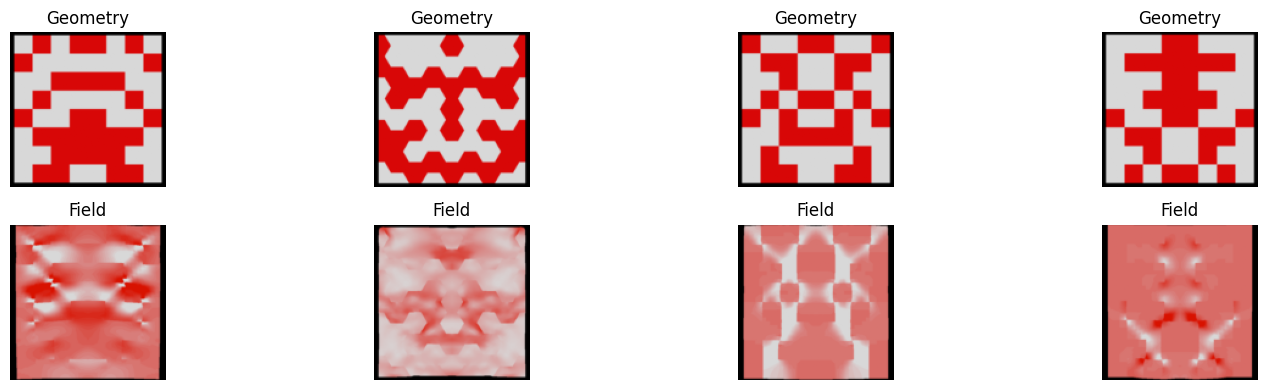

In [ ]:
train_ds = ConcatDataset([
    StressStrainDataset(DATASET_ROOT, s, split="train", img_size=IMG_SIZE, augment=False)
    for s in ALL_SUBDATASETS
])
val_ds = ConcatDataset([
    StressStrainDataset(DATASET_ROOT, s, split="test", img_size=IMG_SIZE, augment=False)
    for s in ALL_SUBDATASETS
])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, persistent_workers=True, prefetch_factor=4,
                          num_workers=4, pin_memory=(DEVICE == "cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=(DEVICE == "cuda"))

print(f"Train : {len(train_ds)} images (aug=True)  across {len(ALL_SUBDATASETS)} subdatasets")
print(f"Val   : {len(val_ds)} images (aug=False) across {len(ALL_SUBDATASETS)} subdatasets")

geo, fld = next(iter(train_loader))
print(f"Batch — geometry: {geo.shape}  field: {fld.shape}")

fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for i in range(min(4, BATCH_SIZE)):
    axes[0, i].imshow(geo[i].permute(1, 2, 0).numpy()); axes[0, i].set_title("Geometry"); axes[0, i].axis("off")
    axes[1, i].imshow(fld[i].permute(1, 2, 0).numpy()); axes[1, i].set_title("Field");    axes[1, i].axis("off")
plt.tight_layout(); plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Hybrid CNN-Transformer (ViTAutoencoder)
# Input : (B, 3, 128, 128)  geometry image
# Output: (B, 3, 128, 128)  predicted stress/strain field
# ══════════════════════════════════════════════════════════════════════════════

def make_2d_sinpos_embed(h, w, dim):
    assert dim % 4 == 0
    half   = dim // 4
    grid_y, grid_x = torch.meshgrid(
        torch.arange(h, dtype=torch.float32) / h,
        torch.arange(w, dtype=torch.float32) / w,
        indexing='ij')
    freq  = torch.exp(-math.log(10000.0) * torch.arange(half, dtype=torch.float32) / half)
    y_ang = grid_y.reshape(-1, 1) * freq.reshape(1, -1)
    x_ang = grid_x.reshape(-1, 1) * freq.reshape(1, -1)
    pos   = torch.cat([y_ang.sin(), y_ang.cos(), x_ang.sin(), x_ang.cos()], dim=-1)
    return pos.unsqueeze(0)  # (1, h*w, dim)


class ResBlock(nn.Module):
    def __init__(self, inc):
        super().__init__()
        self.res = nn.Sequential(
            nn.Conv2d(inc, inc, 3, padding=1), nn.GroupNorm(8, inc), nn.SiLU(),
            nn.Conv2d(inc, inc, 3, padding=1), nn.GroupNorm(8, inc))
    def forward(self, x):
        return x + self.res(x)


class FuseBlock(nn.Module):
    def __init__(self, inc, outc, num_res=2):
        super().__init__()
        self.fuse = nn.Sequential(nn.Conv2d(inc, outc, 3, padding=1), nn.SiLU())
        self.res  = nn.Sequential(*[ResBlock(outc) for _ in range(num_res)])
    def forward(self, x):
        return self.res(self.fuse(x))


class UpSample(nn.Module):
    """Bilinear upsample → concat skip → FuseBlock."""
    def __init__(self, inc, outc, skipc, fuse_res=2):
        super().__init__()
        self.up   = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(inc, outc, 3, padding=1),
            nn.SiLU())
        self.fuse = FuseBlock(outc + skipc, outc, num_res=fuse_res)
    def forward(self, x, skip):
        x = self.up(x)
        if skip.shape[-2:] != x.shape[-2:]:
            skip = F.interpolate(skip, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return self.fuse(torch.cat([x, skip], dim=1))


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(nn.Linear(dim, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, dim))
    def forward(self, x):
        xn = self.norm1(x); x = x + self.attn(xn, xn, xn)[0]
        x  = x + self.mlp(self.norm2(x))
        return x


class Encoder(nn.Module):
    """128×128 input → 8×8 bottleneck. Skip features at 64×64, 32×32, 16×16."""
    def __init__(self, inc, embed_dim):
        super().__init__()
        self.initial = nn.Conv2d(inc, 64, 7, stride=2, padding=3)
        self.layer1  = nn.Sequential(*[ResBlock(64) for _ in range(3)],
                                     nn.Conv2d(64, 128, 3, stride=2, padding=1))
        self.layer2  = nn.Sequential(*[ResBlock(128) for _ in range(5)],
                                     nn.Conv2d(128, 256, 3, stride=2, padding=1))
        self.layer3  = nn.Sequential(*[ResBlock(256) for _ in range(3)],
                                     nn.Conv2d(256, embed_dim, 3, stride=2, padding=1))
    def forward(self, x):
        s64 = F.silu(self.initial(x))
        s32 = F.silu(self.layer1(s64))
        s16 = F.silu(self.layer2(s32))
        s8  = F.silu(self.layer3(s16))
        return [s64, s32, s16, s8.flatten(2).transpose(1, 2)], 8, 8


class Decoder(nn.Module):
    """8×8 → 128×128 with skip connections and multi-scale Sigmoid outputs."""
    def __init__(self, embed_dim, outc, inc=3):
        super().__init__()
        self.proj   = nn.Linear(embed_dim, embed_dim)
        self.up0    = UpSample(embed_dim, 256, 256, fuse_res=3)
        self.up1    = UpSample(256, 128, 128, fuse_res=3)
        self.up2    = UpSample(128,  64,  64, fuse_res=3)
        self.up3    = UpSample( 64,  64, inc, fuse_res=3)
        # Sigmoid bounds outputs to [0,1] — required for stable SSIM loss
        self.head32 = nn.Sequential(nn.Conv2d(128, outc, 1), nn.Sigmoid())
        self.head64 = nn.Sequential(nn.Conv2d( 64, outc, 1), nn.Sigmoid())
        self.refine = nn.Sequential(ResBlock(64), nn.Conv2d(64, outc, 1), nn.Sigmoid())

    def forward(self, x, skips, H, W, x_input):
        B, _, C = x.shape
        x      = self.proj(x).transpose(1, 2).view(B, C, H, W)
        x      = self.up0(x, skips[2])
        x      = self.up1(x, skips[1])
        out32  = self.head32(x)
        x      = self.up2(x, skips[0])
        out64  = self.head64(x)
        x      = self.up3(x, x_input)
        out128 = self.refine(x)
        return out128, out64, out32

class ViTAutoencoder(nn.Module):
    """
    Hybrid CNN-Transformer for geometry → stress/strain field prediction.
    Input  shape: (B, 3, 128, 128) — geometry image
    Output shape: (B, 3, 128, 128) — predicted field  (training: 3-scale tuple)
    """
    def __init__(self, img_size=128, inc=3, embed_dim=256, depth=6,
                 heads=8, mlp_dim=512, outc=3):
        super().__init__()
        self.encoder     = Encoder(inc, embed_dim)
        H_bot = W_bot    = img_size // 16
        sinpos           = make_2d_sinpos_embed(H_bot, W_bot, embed_dim)
        self.pos_embed   = nn.Parameter(sinpos)
        self.transformer = nn.Sequential(
            *[TransformerBlock(embed_dim, heads, mlp_dim) for _ in range(depth)])
        self.decoder     = Decoder(embed_dim, outc, inc=inc)

    def forward(self, x):
        skips, H, W = self.encoder(x)
        t = skips[-1] + self.pos_embed
        t = self.transformer(t)
        out128, out64, out32 = self.decoder(t, skips, H, W, x)
        return out128, out64, out32

print("Architecture defined.")
T = ViTAutoencoder()
total = sum(p.numel() for p in T.parameters())
print(f"Total params: {total/1e6:.1f}M")

Architecture defined.
Total params: 17.0M


In [ ]:
from torchmetrics.functional import structural_similarity_index_measure as ssim_func

def stress_field_loss(pred, target):
    """(1 - SSIM) + L1 loss with multi-scale supervision during training."""
    out128, out64, out32 = pred
    tgt64 = F.avg_pool2d(target.float(), 2, 2)
    tgt32 = F.avg_pool2d(target.float(), 4, 4)
    L_ms  = (0.5  * ((1.0 - ssim_func(out64, tgt64, data_range=1.0)) + F.l1_loss(out64, tgt64))
            + 0.25 * ((1.0 - ssim_func(out32, tgt32, data_range=1.0)) + F.l1_loss(out32, tgt32)))
    pred  = out128

    L_ssim  = 1.0 - ssim_func(pred, target.float(), data_range=1.0)
    L_l1    = F.l1_loss(pred, target.float())
    L_total = L_ssim + L_l1 + (L_ms if isinstance(L_ms, torch.Tensor) else 0.0)
    return L_total, {'ssim': (1.0 - L_ssim).item(), 'l1': L_l1.item()}

print("Loss defined: (1-SSIM) + L1")


Loss defined: (1-SSIM) + L1


In [ ]:
T = ViTAutoencoder(img_size=IMG_SIZE, inc=3, outc=3,
                   embed_dim=256, depth=6, heads=8, mlp_dim=512).to(DEVICE)

opt_T     = AdamW(T.parameters(), lr=1e-4, weight_decay=5e-3)
scaler    = torch.amp.GradScaler(enabled=USE_AMP)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                opt_T, mode='min', patience=15, factor=0.5, min_lr=1e-6)
ssim_eval = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)

best_val_loss = float('inf')
best_state    = None
patience      = 30
patience_ctr  = patience

total = sum(p.numel() for p in T.parameters())
print(f"Model ready on {DEVICE}  |  {total/1e6:.1f}M params  |  AMP={USE_AMP}")
print(f"Training on all {len(ALL_SUBDATASETS)} subdatasets")

Model ready on cuda  |  17.0M params  |  AMP=False
Training on all 10 subdatasets


Epoch 1/25:   0%|          | 0/4400 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Ep    1 | train 0.4166 | val 0.3231 | SSIM 0.8696 | R² 0.8909 | lr 1.00e-04 | pat 30


Ep    2 | train 0.2982 | val 0.2908 | SSIM 0.8851 | R² 0.8995 | lr 1.00e-04 | pat 30


Ep    3 | train 0.2764 | val 0.2739 | SSIM 0.8928 | R² 0.9059 | lr 1.00e-04 | pat 30


Ep    4 | train 0.2656 | val 0.2653 | SSIM 0.8977 | R² 0.9096 | lr 1.00e-04 | pat 30


...

Ep   21 | train 0.2350 | val 0.2377 | SSIM 0.9093 | R² 0.9075 | lr 1.00e-04 | pat 30


Ep   22 | train 0.2349 | val 0.2395 | SSIM 0.9095 | R² 0.9124 | lr 1.00e-04 | pat 29


Ep   23 | train 0.2345 | val 0.2383 | SSIM 0.9090 | R² 0.9063 | lr 1.00e-04 | pat 28


Ep   24 | train 0.2340 | val 0.2379 | SSIM 0.9095 | R² 0.9079 | lr 1.00e-04 | pat 27


Ep   25 | train 0.2338 | val 0.2375 | SSIM 0.9097 | R² 0.9082 | lr 1.00e-04 | pat 30

Restored best model  (val_loss=0.2375)


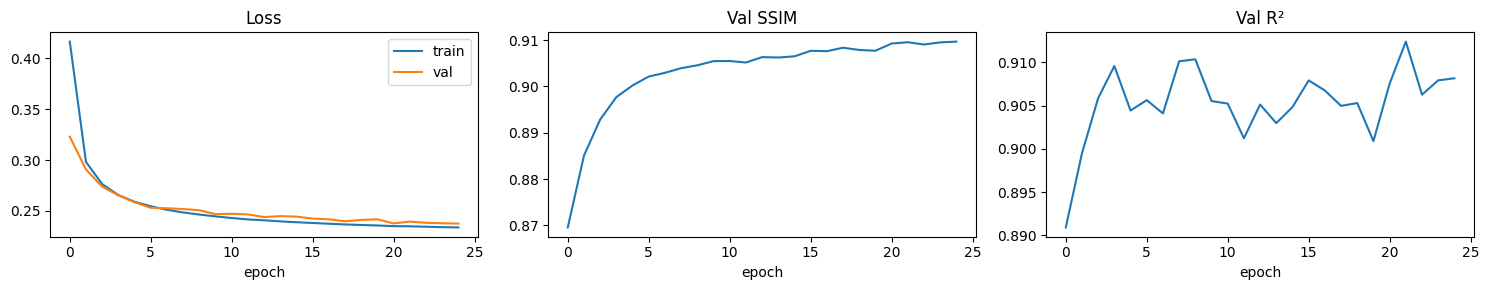

In [ ]:
train_losses, val_losses, val_ssims, val_r2s = [], [], [], []

for epoch in range(EPOCHS):
    if patience_ctr < 0:
        print("Early stopping."); break

    # ── train ──────────────────────────────────────────────────────────────
    T.train()
    ep_loss = 0.0
    bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for geo, fld in bar:
        geo, fld = geo.to(DEVICE), fld.to(DEVICE)
        opt_T.zero_grad(set_to_none=True)
        with torch.amp.autocast(DEVICE, enabled=USE_AMP):
            pred  = T(geo)
            loss, comps = stress_field_loss(pred, fld)
        scaler.scale(loss).backward()
        scaler.unscale_(opt_T)
        torch.nn.utils.clip_grad_norm_(T.parameters(), 1.0)
        scaler.step(opt_T); scaler.update()
        ep_loss += loss.item()
        bar.set_postfix(loss=f"{loss.item():.4f}", **{k: f"{v:.3f}" for k, v in comps.items()})

    ep_loss /= len(train_loader)
    train_losses.append(ep_loss)

    # ── validate ────────────────────────────────────────────────────────────
    T.eval()
    val_loss = val_ssim = 0.0
    ss_res = ss_tot = 0.0          # accumulators for R²

    with torch.no_grad():
        for geo, fld in val_loader:
            geo, fld = geo.to(DEVICE), fld.to(DEVICE)
            with torch.amp.autocast(DEVICE, enabled=USE_AMP):
                pred = T(geo)                          # now always a tuple
                vl, _ = stress_field_loss(pred, fld)
            pred128 = pred[0]                          # unpack for metrics
            val_loss += vl.item()
            val_ssim += ssim_eval(pred128.float(), fld.float()).item()

            p = pred128.float(); t = fld.float()
            ss_res += ((p - t) ** 2).sum().item()
            ss_tot += ((t - t.mean(dim=[1,2,3], keepdim=True)) ** 2).sum().item()  # per-image mean, not batch mean

    val_loss /= len(val_loader)
    val_ssim /= len(val_loader)
    val_r2    = 1.0 - ss_res / (ss_tot + 1e-8)

    val_losses.append(val_loss)
    val_ssims.append(val_ssim)
    val_r2s.append(val_r2)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.cpu().clone() for k, v in T.state_dict().items()}
        patience_ctr  = patience
    else:
        patience_ctr -= 1

    lr = opt_T.param_groups[0]['lr']
    print(f"Ep {epoch+1:4d} | train {ep_loss:.4f} | val {val_loss:.4f} | "
          f"SSIM {val_ssim:.4f} | R² {val_r2:.4f} | lr {lr:.2e} | pat {patience_ctr}")

# restore best
if best_state:
    T.load_state_dict(best_state)
    print(f"\nRestored best model  (val_loss={best_val_loss:.4f})")

# curves
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(train_losses, label='train'); axes[0].plot(val_losses, label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(val_ssims); axes[1].set_title('Val SSIM')
axes[2].plot(val_r2s);   axes[2].set_title('Val R²')
for ax in axes: ax.set_xlabel('epoch')
plt.tight_layout()
plt.show()


Restored best model  (val_loss=0.2375)


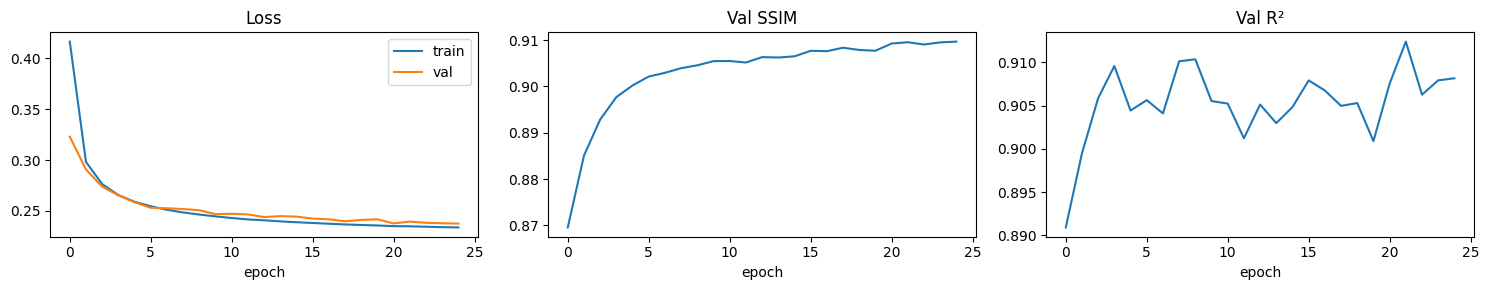

In [ ]:
# restore best
if best_state:
    T.load_state_dict(best_state)
    print(f"\nRestored best model  (val_loss={best_val_loss:.4f})")

# curves
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(train_losses, label='train'); axes[0].plot(val_losses, label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(val_ssims); axes[1].set_title('Val SSIM')
axes[2].plot(val_r2s);   axes[2].set_title('Val R²')
for ax in axes: ax.set_xlabel('epoch')
plt.tight_layout(); plt.show()

In [ ]:
CKPT_PATH = f"stress_vit_ALL.pth"
torch.save(best_state, CKPT_PATH)
print(f"Checkpoint saved → {CKPT_PATH}")

Checkpoint saved → stress_vit_ALL.pth


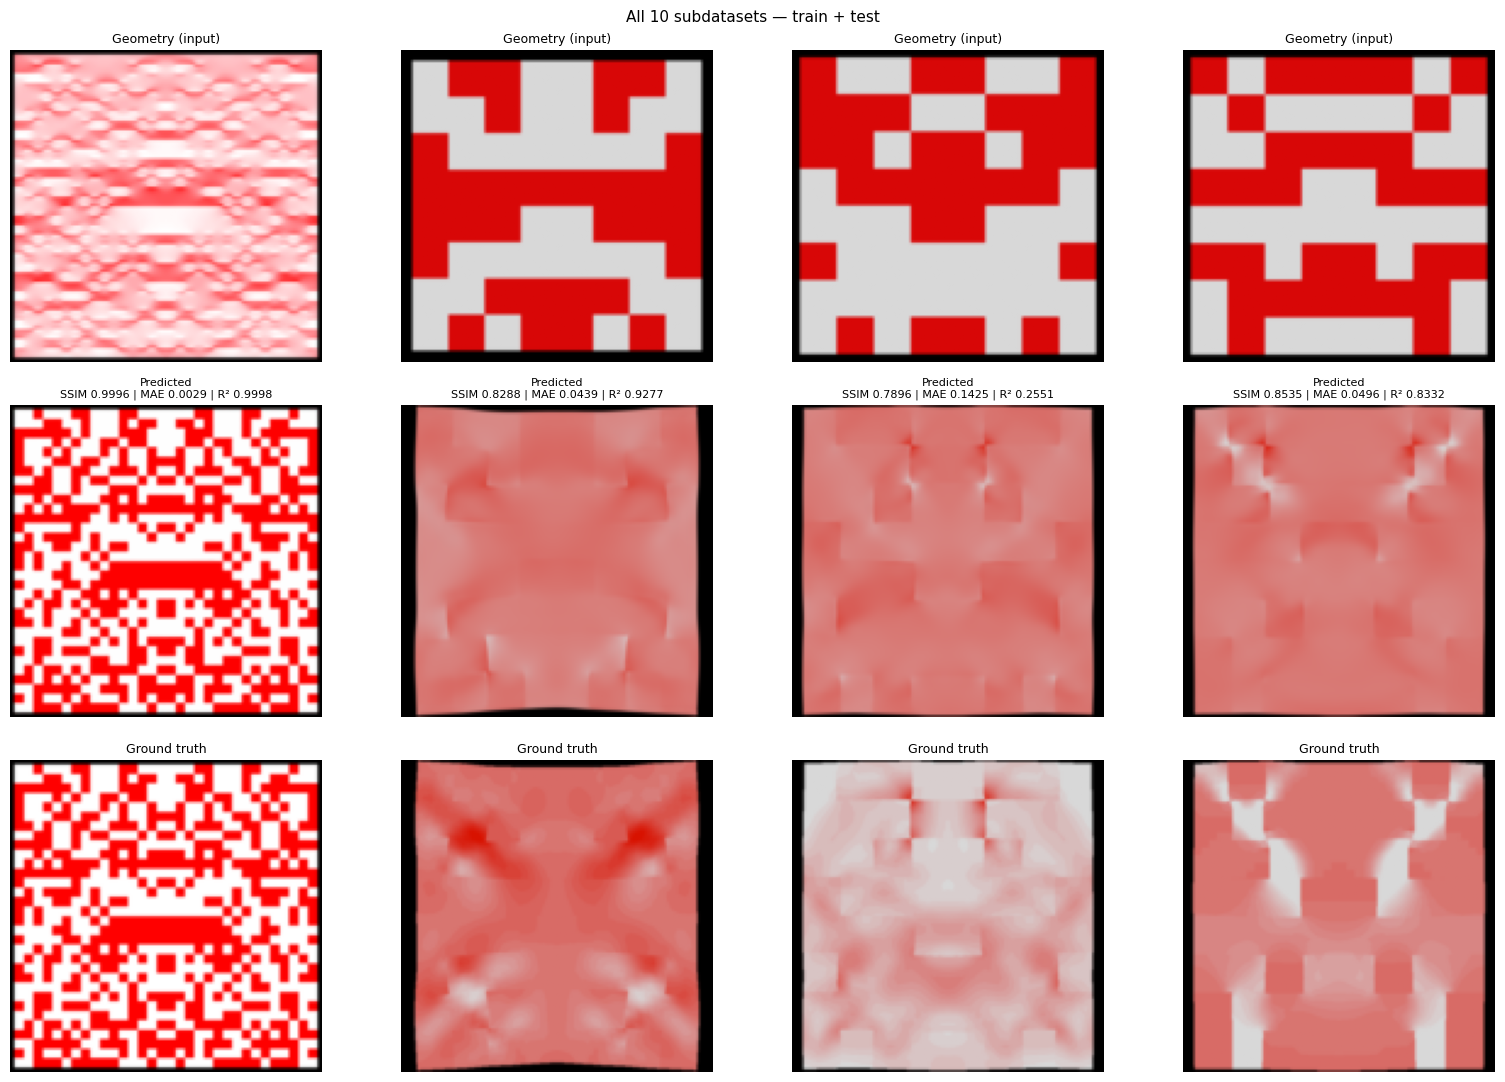

In [ ]:
T.eval()
geo_batch, fld_batch = next(iter(val_loader))
geo_batch, fld_batch = geo_batch.to(DEVICE), fld_batch.to(DEVICE)

with torch.no_grad():
    with torch.amp.autocast(DEVICE, enabled=USE_AMP):
        pred_batch = T(geo_batch)

n = min(4, geo_batch.shape[0])
fig, axes = plt.subplots(3, n, figsize=(n * 4, 11))

for i in range(n):
    geo_img  = geo_batch[i].cpu().permute(1, 2, 0).float().numpy()
    fld_img  = fld_batch[i].cpu().permute(1, 2, 0).float().numpy()
    pred_img = pred_batch[0][i].cpu().permute(1, 2, 0).float().numpy()

    p = pred_batch[0][i:i+1].float()
    t = fld_batch[i:i+1].float()

    ssim_val = ssim_eval(p, t).item()
    mae_val  = (p - t).abs().mean().item()
    ss_res   = ((p - t) ** 2).sum().item()
    ss_tot   = ((t - t.mean()) ** 2).sum().item()
    r2_val   = 1.0 - ss_res / (ss_tot + 1e-8)

    axes[0, i].imshow(geo_img)
    axes[0, i].set_title("Geometry (input)", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(pred_img)
    axes[1, i].set_title(
        f"Predicted\nSSIM {ssim_val:.4f} | MAE {mae_val:.4f} | R² {r2_val:.4f}",
        fontsize=8)
    axes[1, i].axis("off")

    axes[2, i].imshow(fld_img)
    axes[2, i].set_title("Ground truth", fontsize=9)
    axes[2, i].axis("off")

plt.suptitle(
    f"All {len(ALL_SUBDATASETS)} subdatasets — train + test",
    fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
from google.colab import files
files.download(CKPT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM target: encoder_last → Conv2d
Found 400 images — visualising 4 samples


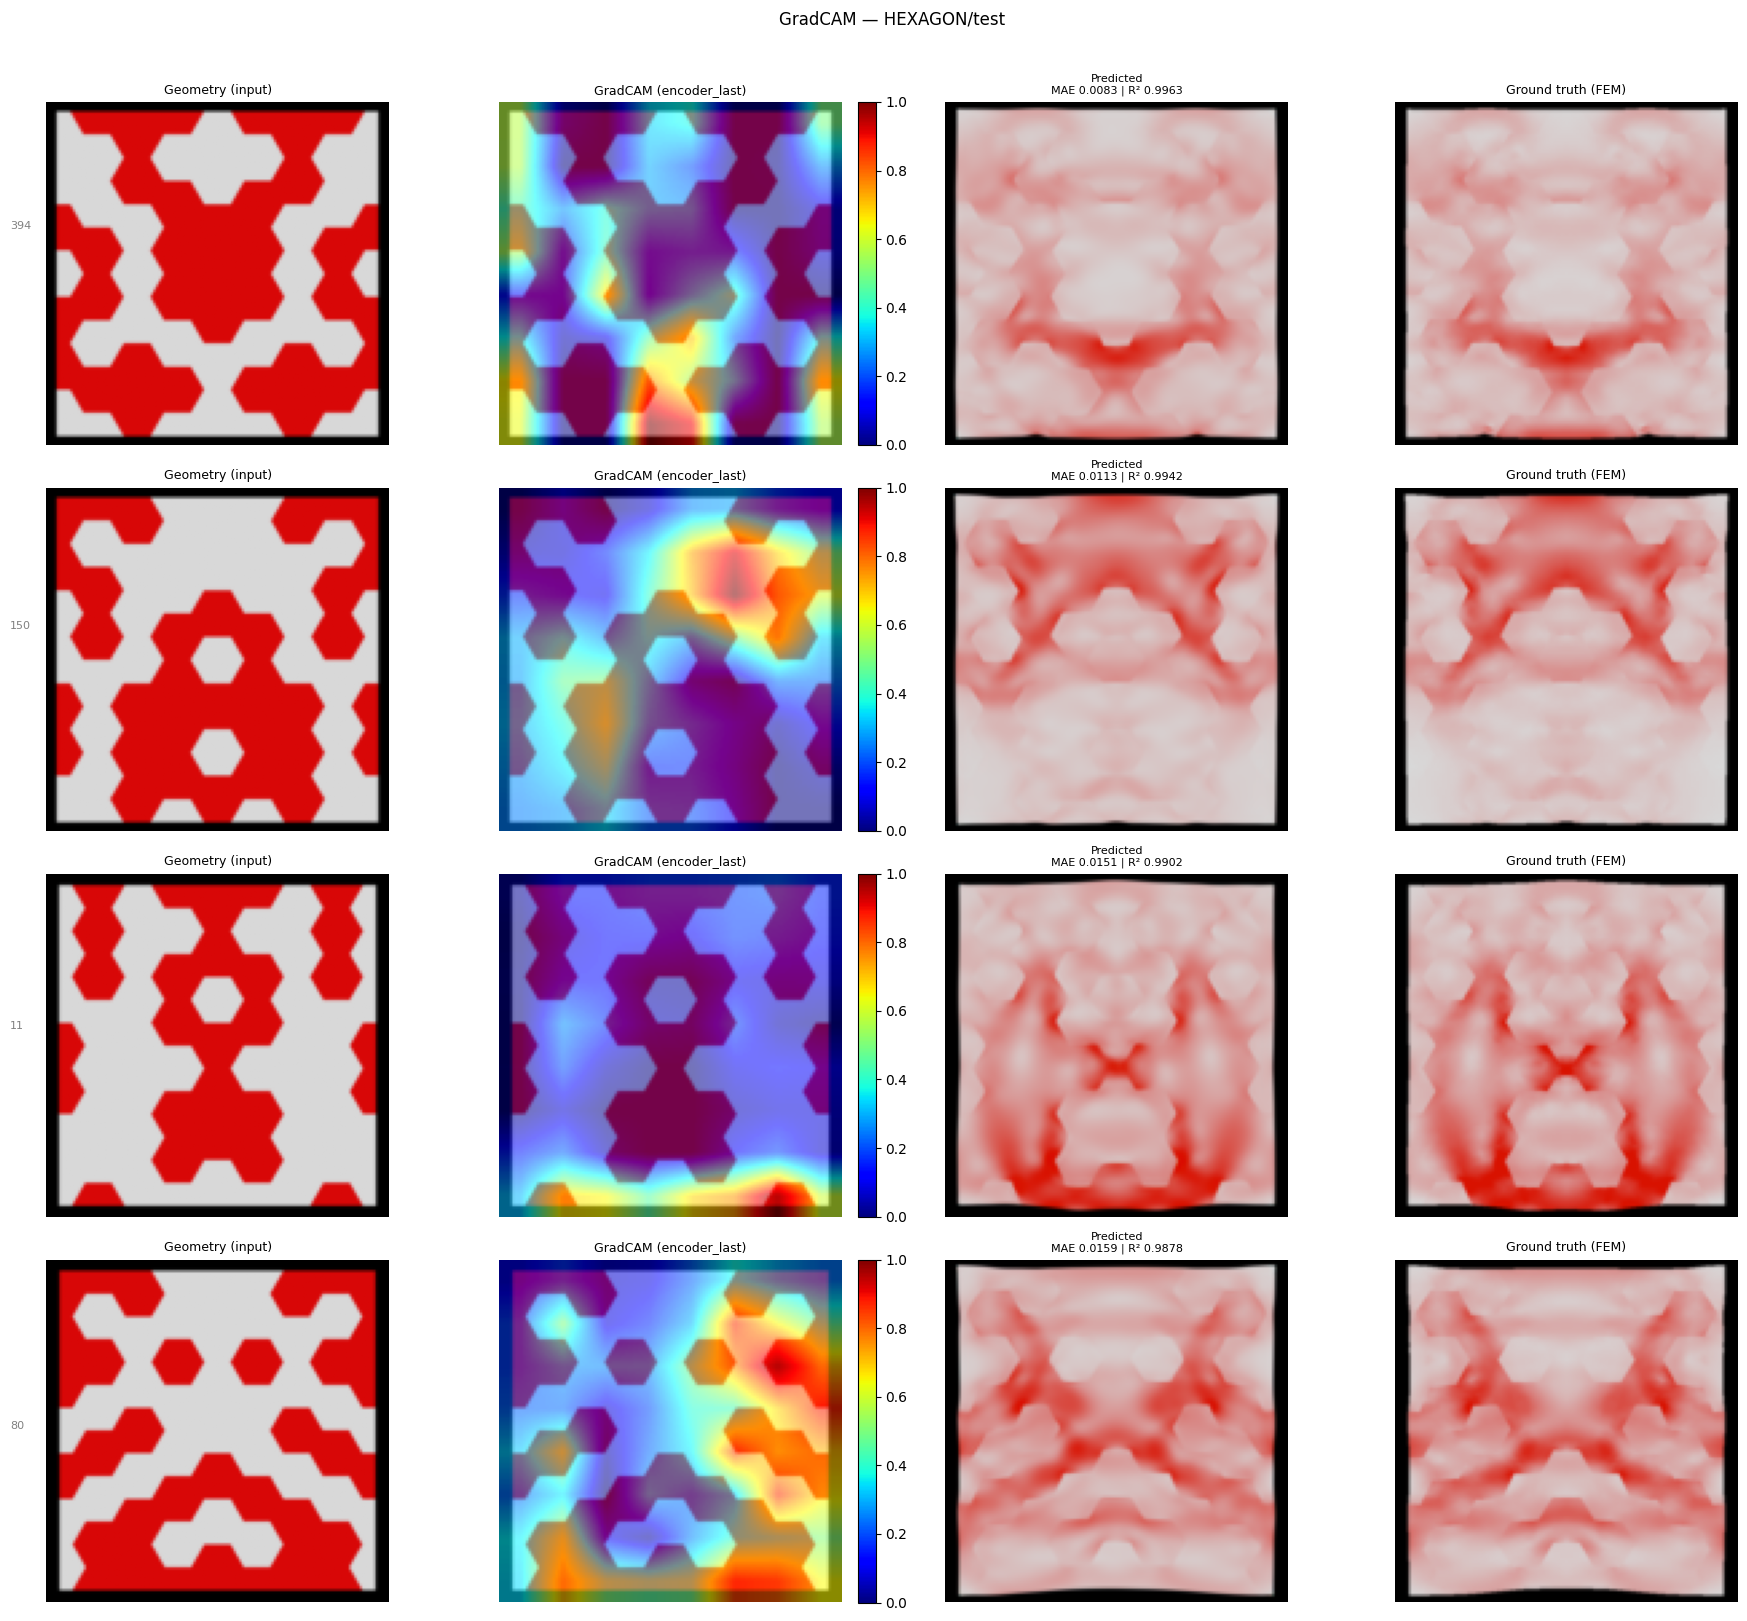

GradCAM visualisation complete.


In [ ]:
# ── GradCAM visualisation (runs after training, reuses model T) ───────────────
import random, glob, os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ── Config ────────────────────────────────────────────────────────────────────
GRADCAM_SUBDATASET  = "HEXAGON"          # change to any subdataset you like
GRADCAM_SPLIT       = "test"           # "train" or "test"
GRADCAM_NUM_SAMPLES = 4
GRADCAM_TARGET_LAYER_NAME = "encoder_last"   # encoder_last | decoder_32 | decoder_64
GRADCAM_SEED        = 42

# ── Target layer map ──────────────────────────────────────────────────────────
layer_map = {
    "encoder_last": T.encoder.layer3[-1],       # Conv2d before bottleneck (8×8)
    "decoder_32":   T.decoder.up1.fuse.res[-1], # decoder at 32×32
    "decoder_64":   T.decoder.up2.fuse.res[-1], # decoder at 64×64
}
target_layer = layer_map[GRADCAM_TARGET_LAYER_NAME]
print(f"GradCAM target: {GRADCAM_TARGET_LAYER_NAME} → {target_layer.__class__.__name__}")

# ── Target function ───────────────────────────────────────────────────────────
class MeanFieldTarget:
    """Works for both eval-mode (single tensor) and train-mode (tuple) output."""
    def __call__(self, model_output):
        out = model_output[0] if isinstance(model_output, (tuple, list)) else model_output
        return out.mean()

# ── Find & sample images ──────────────────────────────────────────────────────
pattern = os.path.join(DATASET_ROOT, GRADCAM_SUBDATASET, GRADCAM_SPLIT, "*.png")
files   = sorted(glob.glob(pattern))
assert files, f"No PNGs found at: {pattern}"
random.seed(GRADCAM_SEED)
selected = random.sample(files, min(GRADCAM_NUM_SAMPLES, len(files)))
print(f"Found {len(files)} images — visualising {len(selected)} samples")

# ── Run GradCAM ───────────────────────────────────────────────────────────────
T.eval()
cam       = GradCAM(model=T, target_layers=[target_layer])
target_fn = MeanFieldTarget()

fig, axes = plt.subplots(len(selected), 4, figsize=(18, 4 * len(selected)))
if len(selected) == 1:
    axes = axes[None, :]   # keep 2-D indexing

for row, fpath in enumerate(selected):
    # load
    img  = Image.open(fpath).convert("RGB")
    w    = img.width // 2
    geo  = img.crop((0, 0, w, img.height)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    fld  = img.crop((w, 0, img.width, img.height)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    geo_np  = np.array(geo).astype(np.float32) / 255.0
    fld_np  = np.array(fld).astype(np.float32) / 255.0
    geo_t   = torch.from_numpy(geo_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    # GradCAM heatmap
    grayscale_cam = cam(input_tensor=geo_t, targets=[target_fn],
                        aug_smooth=False, eigen_smooth=False)[0]   # (H, W)
    cam_overlay   = show_cam_on_image(geo_np, grayscale_cam, use_rgb=True)

    # prediction
    with torch.no_grad():
        pred = T(geo_t)
        if isinstance(pred, (tuple, list)):
            pred = pred[0]
    pred_np = pred[0].cpu().permute(1, 2, 0).numpy()

    # metrics (global residuals — more meaningful than per-image R²)
    p = pred[0].cpu(); t = torch.from_numpy(fld_np).permute(2, 0, 1)
    mae  = (p - t).abs().mean().item()
    ss_r = ((p - t) ** 2).sum().item()
    ss_t = ((t - t.mean()) ** 2).sum().item()
    r2   = 1.0 - ss_r / (ss_t + 1e-8)

    sample_name = os.path.splitext(os.path.basename(fpath))[0]

    axes[row, 0].imshow(geo_np);                        axes[row, 0].set_title("Geometry (input)", fontsize=9)
    axes[row, 1].imshow(cam_overlay)
    sm = plt.cm.ScalarMappable(cmap="jet", norm=plt.Normalize(0, 1))
    sm.set_array([])
    plt.colorbar(sm, ax=axes[row, 1], fraction=0.046, pad=0.04)
    axes[row, 1].set_title(f"GradCAM ({GRADCAM_TARGET_LAYER_NAME})", fontsize=9)
    axes[row, 2].imshow(pred_np);                       axes[row, 2].set_title(f"Predicted\nMAE {mae:.4f} | R² {r2:.4f}", fontsize=8)
    axes[row, 3].imshow(fld_np);                        axes[row, 3].set_title("Ground truth (FEM)", fontsize=9)
    for ax in axes[row]: ax.axis("off")
    fig.text(0.01, 1 - (row + 0.5) / len(selected), sample_name, va="center", fontsize=8, color="gray")

plt.suptitle(f"GradCAM — {GRADCAM_SUBDATASET}/{GRADCAM_SPLIT}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print("GradCAM visualisation complete.")